In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from utils.graph_construction import cal_spatial_network
from scipy import sparse
import squidpy as sq

sc.set_figure_params(scanpy=True, dpi=80, dpi_save=600, frameon=True, vector_friendly=False, fontsize=12, figsize=None, color_map=None, format='pdf', facecolor=None, transparent=True, ipython_format='png2x')
sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

2025-01-24 08:39:30.224587: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-24 08:39:30.274545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-24 08:39:30.884127: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.13.1 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.2 igraph==0.11.8 louvain==0.8.2 pynndescent==0.5.12
squidpy==1.6.1


In [2]:
# load the pre-processed dataset
merfish_adata = sc.read_h5ad('/home/featurize/work/moscot/data/MERFISH/merfish3d.h5ad')
merfish_adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

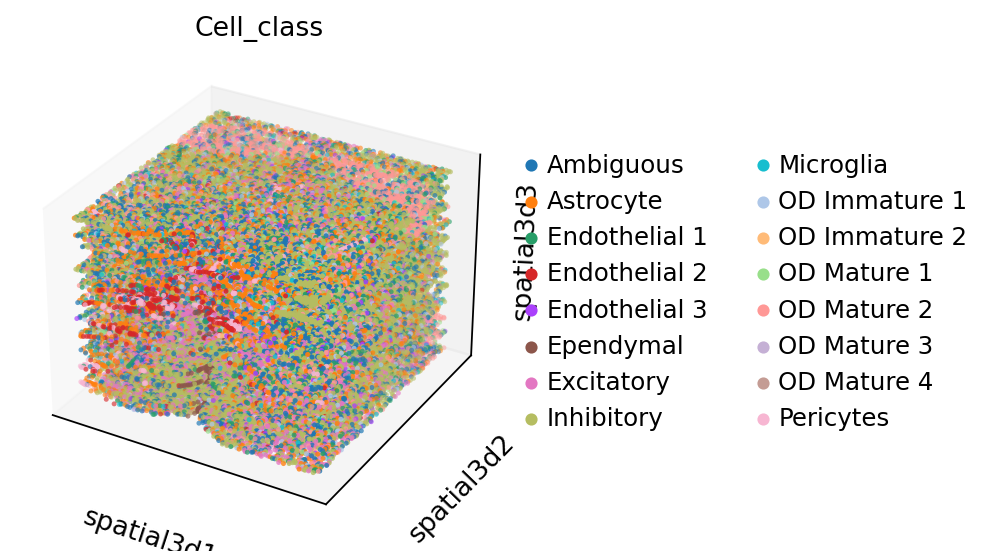

In [3]:
sc.pl.embedding(merfish_adata, basis="spatial3d", projection="3d", color="Cell_class")

In [4]:
adata_list = []
section_ids = merfish_adata.obs['batch'].unique().to_numpy()
adata_list = []
adj_list = []

for section_id in section_ids:
    adata = merfish_adata[merfish_adata.obs['batch'] == section_id]
    batch_id = adata.obs['batch'].values[0]
    print(batch_id)
    adata.X = sparse.csc_matrix(adata.X)
    adata.var_names_make_unique(join="++")    
    
    # make spot name unique
    adata.obs_names = [x + '_' + section_id for x in adata.obs_names]
    sc.pp.pca(adata)
    cal_spatial_network(adata, model='KNN', k_cutoff=1)
        
    adj_list.append(adata.uns['adj'])
    adata_list.append(adata)

0
Calculating spatial neighbor graph ...
The graph contains 6509 edges, 6509 cells
1.0 neighbors per cell on average
1
Calculating spatial neighbor graph ...
The graph contains 6412 edges, 6412 cells
1.0 neighbors per cell on average
2
Calculating spatial neighbor graph ...
The graph contains 6507 edges, 6507 cells
1.0 neighbors per cell on average
3
Calculating spatial neighbor graph ...
The graph contains 6605 edges, 6605 cells
1.0 neighbors per cell on average
4
Calculating spatial neighbor graph ...
The graph contains 6185 edges, 6185 cells
1.0 neighbors per cell on average
5
Calculating spatial neighbor graph ...
The graph contains 6154 edges, 6154 cells
1.0 neighbors per cell on average
6
Calculating spatial neighbor graph ...
The graph contains 6111 edges, 6111 cells
1.0 neighbors per cell on average
7
Calculating spatial neighbor graph ...
The graph contains 6144 edges, 6144 cells
1.0 neighbors per cell on average
8
Calculating spatial neighbor graph ...
The graph contains 5799

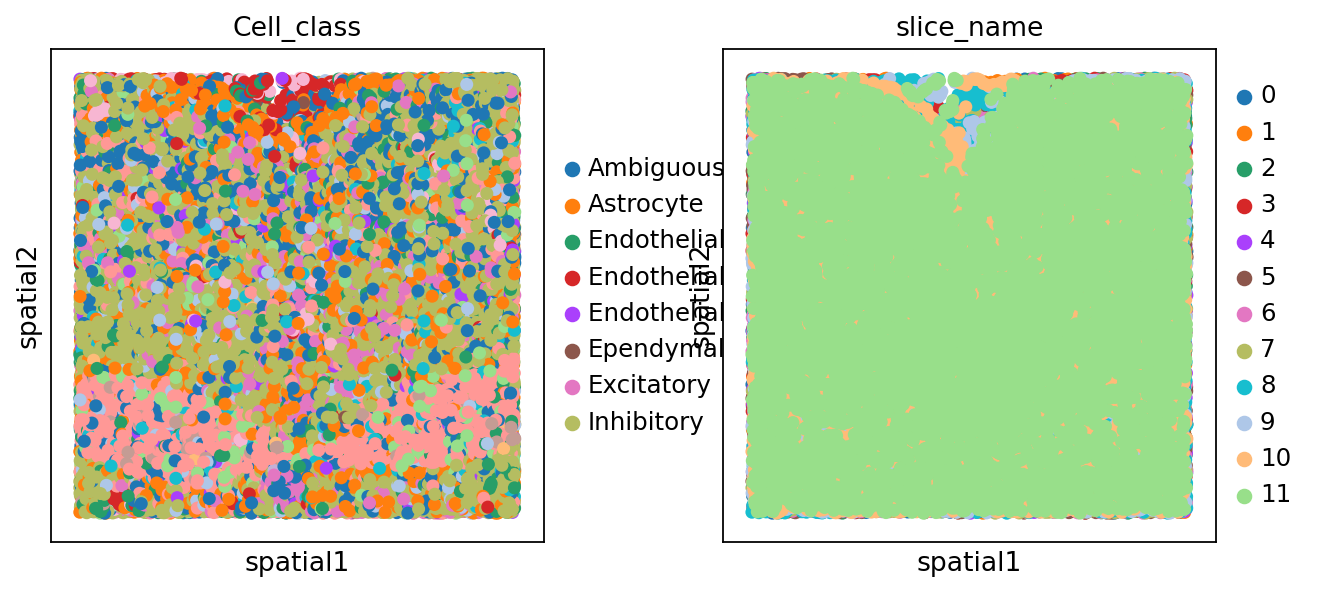

In [5]:
import anndata as ad

adata_concat = ad.concat(adata_list, label='slice_name', keys=section_ids)
sc.pl.spatial(adata_concat, color=['Cell_class', 'slice_name'], spot_size=0.03)

In [6]:
from scipy.sparse import block_diag

adata_concat = ad.concat(adata_list, label='slice_name', keys=section_ids)
adj_concat = block_diag(adj_list)
adata_concat.uns['edge_list'] = np.nonzero(adj_concat)

In [7]:
from graph import AlignDG

iter_comb = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)]
adata_concat, pis = AlignDG.train_AlignDG(adata=adata_concat, beta=0.3, alpha1=1, alpha2=0.9, lamb=1, iter_comb=iter_comb)

  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplet at epoch 500
Processing datasets ('0', '1')
Processing datasets ('1', '2')
Processing datasets ('2', '3')
Processing datasets ('3', '4')
Processing datasets ('4', '5')
Processing datasets ('5', '6')
Processing datasets ('6', '7')
Processing datasets ('7', '8')
Processing datasets ('8', '9')
Processing datasets ('9', '10')
Processing datasets ('10', '11')


# Epoch 599, loss: 2.348, gene_recon: 2.312, triplet loss: 0.036338478326797485:  19%|█▉        | 97/500 [01:11<00:11, 36.51it/s] 

Update spot triplet at epoch 600
Processing datasets ('0', '1')
Processing datasets ('1', '2')
Processing datasets ('2', '3')
Processing datasets ('3', '4')
Processing datasets ('4', '5')


# Epoch 599, loss: 2.348, gene_recon: 2.312, triplet loss: 0.036338478326797485:  19%|█▉        | 97/500 [01:28<00:11, 36.51it/s]

...

# Epoch 899, loss: 1.977, gene_recon: 1.937, triplet loss: 0.040465567260980606:  79%|███████▉  | 397/500 [03:37<00:02, 35.93it/s]

Update spot triplet at epoch 900
Processing datasets ('0', '1')
Processing datasets ('1', '2')
Processing datasets ('2', '3')


# Epoch 899, loss: 1.977, gene_recon: 1.937, triplet loss: 0.040465567260980606:  79%|███████▉  | 397/500 [03:49<00:02, 35.93it/s]

Processing datasets ('3', '4')
Processing datasets ('4', '5')
Processing datasets ('5', '6')
Processing datasets ('6', '7')
Processing datasets ('7', '8')
Processing datasets ('8', '9')
Processing datasets ('9', '10')
Processing datasets ('10', '11')


# Epoch 999, loss: 1.886, gene_recon: 1.846, triplet loss: 0.03983465954661369: 100%|██████████| 500/500 [04:28<00:00,  1.87it/s] 


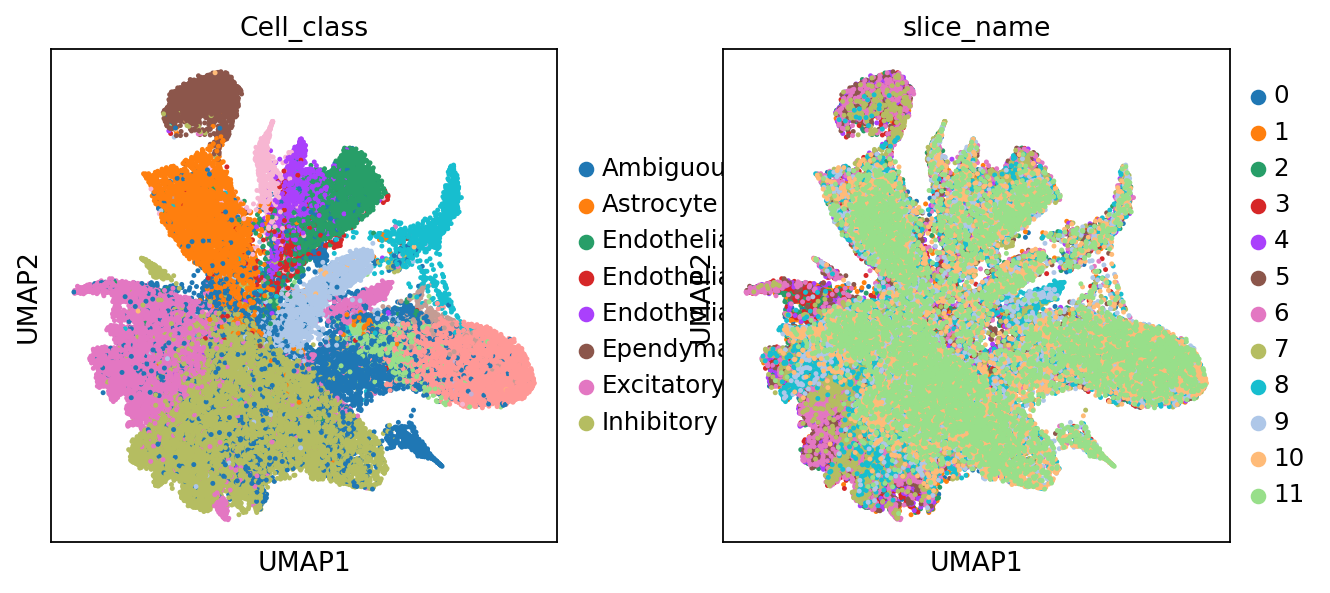

In [8]:
sc.pp.neighbors(adata_concat, use_rep='latent')
sc.tl.umap(adata_concat)
sc.pl.umap(adata_concat, color=['Cell_class', 'slice_name'], size=20)

### Visualize the alignment result

In [9]:
adata1_harm_df = pd.DataFrame({
    'index': range(adata_list[0].shape[0]),
    'x': adata_list[0].obsm['spatial'][:, 0],
    'y': adata_list[0].obsm['spatial'][:, 1],
    'domain': adata_list[0].obs['Cell_class'].astype('category'),
})

adata2_harm_df = pd.DataFrame({
    'index': range(adata_list[1].shape[0]),
    'x': adata_list[1].obsm['spatial'][:, 0],
    'y': adata_list[1].obsm['spatial'][:, 1],
    'domain': adata_list[1].obs['Cell_class'].astype('category'),
})

In [10]:
count = 0
ref_raw_list = []
pi = pis[0]
for i in range(pi.shape[0]):
    source_domain = adata_list[0].obs['Cell_class'][i]
    max_align = pi[i].argsort()[-1]
    target_domain = adata_list[1].obs['Cell_class'].values[max_align]
    ref_raw_list.append(max_align)
    if source_domain == target_domain:
        count = count + 1

print(count / len(ref_raw_list))

index_harm = np.array(ref_raw_list) 
matching_harm = np.array([range(index_harm.shape[0]), index_harm])

/tmp/ipykernel_5638/2218435697.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  source_domain = adata_list[0].obs['Cell_class'][i]
/tmp/ipykernel_5638/2218435697.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  source_domain = adata_list[0].obs['Cell_class'][i]


0.782915962513443


dataset1: 16 cell types; dataset2: 16 cell types; 
                    Total :16 celltypes; Overlap: 16 cell types 
                    Not overlap :[[]]
Subsampled 300 pairs from 6509


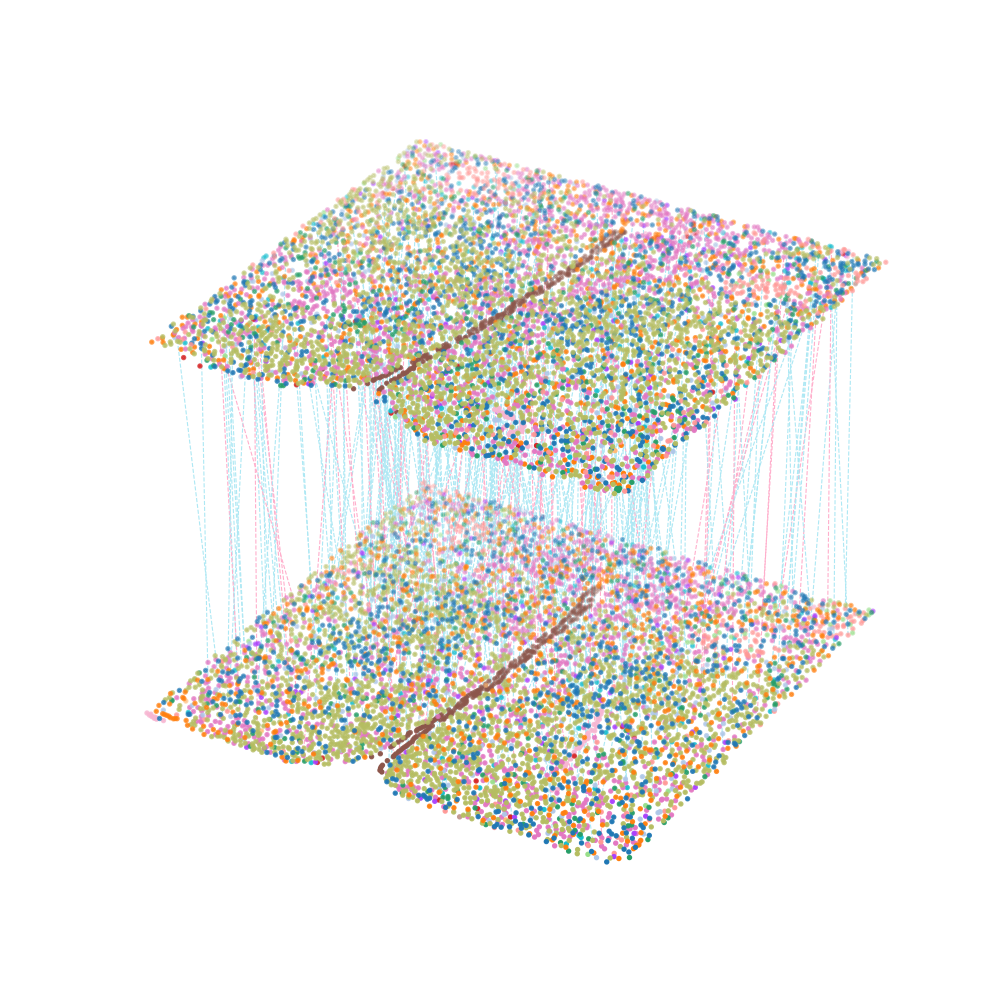

In [11]:
from utils.visualize import Build3D

multi_align = Build3D(adata2_harm_df, adata1_harm_df, matching_harm, meta='domain', scale_coordinate=True, subsample_size=300, exchange_xy=False)
multi_align.draw_3D(size=[8, 8], line_width=0.5, point_size=[2, 2], hide_axis=True, show_error=True, line_alpha=1)

### Evaluate all slices

In [35]:
def mapping_accuracy(adatas, key_obs, mapping_pi):
    count = 0
    ref_raw_list = []
    for i in range(mapping_pi.shape[0]):
        source_domain = adatas[0].obs[key_obs][i]
        max_align = mapping_pi[i].argsort()[-1]
        target_domain = adatas[1].obs[key_obs].values[max_align]
        ref_raw_list.append(max_align)
        if source_domain == target_domain:
            count = count + 1
    
    return count / len(ref_raw_list)

In [36]:
paa_list = []
smr_list = []
i = 0
for comb in iter_comb:
    ref = comb[0]
    query = comb[1]
    adata_source = adata_list[ref]
    adata_aligned = adata_list[query]
    sub_adata_list = [adata_source, adata_aligned]
    adata_cat = adata_source.concatenate(adata_aligned)
    paa = mapping_accuracy(sub_adata_list, key_obs='Cell_class', mapping_pi=pis[i])
    i = i + 1
    paa_list.append(paa)

/tmp/ipykernel_5638/3755331049.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_cat = adata_source.concatenate(adata_aligned)
/tmp/ipykernel_5638/943177592.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  source_domain = adatas[0].obs[key_obs][i]
/tmp/ipykernel_5638/3755331049.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_cat = adata_source.concatenate(adata_aligned)
/tmp/ipykernel_5638/943177592.py:5: FutureWarning:

In [37]:
pd.DataFrame(paa_list)

,0
0,0.782916
1,0.810512
2,0.828339
3,0.820742
4,0.817300
5,0.792330
6,0.806742
7,0.775228
8,0.807553
9,0.791989
